# Single headed TinyYOLOv3 (YOLO-KP) ANN-SDNN conversion example

The ANN-SDNN conversion tool performs post-training conversion of full-precision pre-trained ANNs with ReLU activation to a fixed-precision Sigma-Delta ReLU network. The Sigma-Delta network is trainable with backpropagation. The conversion ensures a very minimal drop in performance of the resulting Sigma-Delta network and thus may be used without any fine-tuning.

The conversion tool is built on top of `lava-dl.slayer` tools and is available as `lava-dl.conversion`.

YOLO-KP is a single headed version of TinyYOLOv3 network. This tutorial walks through the ANN-SDNN conversion of YOLO-KP ANN network to an equivalent quantized Sigma-Delta ReLU network and its inference on GPU.

In [1]:
import os
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn.functional as F

from lava.lib.dl import slayer
from lava.lib.dl import conversion
from lava.lib.dl.slayer.object_detection.yolo_base import _yolo as yolo_predict

# Load ANN Network

The YOLO-KP ANN network was trained independently. Here we will take the pre-trained checkpoint and use that to convert the ANN to a Sigma-Delta ReLU network.

In [2]:
device = torch.device('cuda')

ann_state_dict = torch.load('Trained/network.pt', map_location=torch.device('cpu'))
yolo_anchors = torch.tensor([[(0.28, 0.22), (0.38, 0.48), (0.9, 0.78)]]).to(device)

# input normalization
input_mean = torch.tensor([0.485, 0.456, 0.406]).reshape([1, 3, 1, 1, 1])
input_std  = torch.tensor([0.229, 0.224, 0.225]).reshape([1, 3, 1, 1, 1])


In [3]:
network_config = {  # This is the meta information of the structure of the ANN module
    'layers_back_bone.0_convbatch.conv': dict(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1, bias=False),
    'layers_back_bone.2_convbatch.conv': dict(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False),
    'layers_back_bone.4_convbatch.conv': dict(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, bias=False),
    'layers_back_bone.6_convbatch.conv': dict(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1, bias=False),
    'layers_back_bone.8_convbatch.conv': dict(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1, bias=False),
    'layers_back_bone.10_convbatch.conv': dict(in_channels=256, out_channels=256, kernel_size=3, stride=2, padding=1, bias=False),
    'layers_back_bone.12_convbatch.conv': dict(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1, bias=False),
    'layers_back_bone.14_convbatch.conv': dict(in_channels=512, out_channels=256, kernel_size= 1, stride=1, padding=0, bias=False),
    'yolo_0_pre.14_convbatch.conv': dict(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1, bias=False),
    'yolo_0_pre.15_conv': dict(in_channels=512, out_channels=48, kernel_size=1, stride=1, padding=0),
}

### ANN parameter load methods

The following functions load the ANN layer's convolution and batchnorm operations which will then be used for conversion.

In [4]:
def get_conv(ann_state_dict, network_config, key):
    conv_args = network_config.get(key)
    weight = ann_state_dict.get(key + '.weight')
    bias = ann_state_dict.get(key + '.bias')
    conv = torch.nn.Conv2d(**conv_args)
    conv.weight.data = weight
    if bias is not None:
        conv.bias.data = bias
    return conv.eval()

def get_bn(ann_state_dict, out_channels, key):
    batch_norm = torch.nn.BatchNorm2d(out_channels)
    bn_weight = ann_state_dict.get(key + '.bn.weight')
    bn_bias = ann_state_dict.get(key + '.bn.bias')
    bn_running_mean = ann_state_dict.get(key + '.bn.running_mean')
    bn_running_var = ann_state_dict.get(key + '.bn.running_var')
    bn_num_batches_tracked = ann_state_dict.get(key + '.bn.num_batches_tracked')

    if bn_weight is None:
        return None
    else:
        batch_norm.weight.data = bn_weight
        batch_norm.bias.data = bn_bias
        batch_norm.running_mean.data = bn_running_mean
        batch_norm.running_var.data = bn_running_var
        batch_norm.num_batches_tracked = bn_num_batches_tracked
        return batch_norm.eval()


### Sparsity evaluation method

The following function claculates the sparsity of each layer based on the output of each layer and its associated synapse type.

In [5]:
def get_sparsity(slayer_sdnn):
    ann_synops = []
    sdnn_synops = []
    ann_events = []
    sdnn_events = []
    for idx, (blk) in enumerate(slayer_sdnn.blocks):
        if idx == 0:
            continue
        inp = slayer_sdnn.buffer[idx - 1]
        if isinstance(blk, conversion.block.ConvBlock):
            synops = (np.prod(inp.shape) * np.prod(blk.synapse.weight.shape[:3]) / np.prod(blk.synapse.stride))
        elif isinstance(blk, conversion.block.DenseBlock):
            synops = np.prod(blk.synapse.weight.shape)
        else:
            continue
        ann_synops.append(synops)
        sdnn_synops.append(torch.sum(inp > 0) / torch.numel(inp) * synops)
        ann_events.append(torch.numel(slayer_sdnn.buffer[idx]))
        sdnn_events.append(torch.sum(slayer_sdnn.buffer[idx] > 0))

    act_sparsity = (sum(ann_events) / sum(sdnn_events)).item()
    syn_sparsity = (sum(ann_synops) / sum(sdnn_synops)).item()
    return act_sparsity, syn_sparsity

# YOLO prediction function

In [6]:
def yolo(x: torch.tensor, anchors: torch.tensor, clamp_max: float = 5.0) -> torch.tensor:
    N, _, _, _, P, T = x.shape
    return yolo_predict(x, anchors, clamp_max).reshape([N, -1, P, T])

In [7]:
yolo_target = slayer.obd.YOLOtarget(anchors=ann_state_dict['anchors'],
                                    scales=[[16, 16]],
                                    num_classes=11,
                                    ignore_iou_thres=0.5)

test_set = slayer.obd.dataset.BDD(root='./data/bdd100k', dataset='track',
                                  train=False, randomize_seq=False,
                                  seq_len=200)

test_loader = DataLoader(test_set,
                         batch_size=2,
                         shuffle=True,
                         collate_fn=yolo_target.collate_fn,
                         num_workers=4,
                         pin_memory=True)

# Convert ANN to SDNN

Here we will make use of a generic `conversion.network.Network` container which is designed to easily add layers programatically using `add_block` method.

`lava-dl.conversion` provides `translator` module which contains methods to translate convolutional and dense ANN layers to `lava-dl.slayer` compatible form. Note that a `SigmaDeltaReLU` instance is used as the activation. It can be simply a `ReLU` activation in that case the conversion would simply be a quantized ANN with ReLU activation.

Since, in a Sigma-Delta there is a time difference, the Sigma-Delta layers are encapsulated by a `Delta` layer to perform the input encoding and a `Sigma` layer to perform the output decoding.

In [8]:
map_conv_block = conversion.translator.map_conv_block

# Empty network container
slayer_sdnn = slayer.conversion.network.Network()

# Delta encoding layer
activation = slayer.conversion.activation.Delta(threshold=0)
slayer_sdnn.add_block(activation)

# backbone
for idx in range(0, 15, 2):
    conv = get_conv(ann_state_dict, network_config, f'layers_back_bone.{idx}_convbatch.conv')
    bn = get_bn(ann_state_dict, conv.out_channels, f'layers_back_bone.{idx}_convbatch')
    activation = slayer.conversion.activation.SigmaDeltaReLU(threshold=0.02)
    slayer_sdnn.add_block(map_conv_block(conv, bn, activation=activation))

# head
conv = get_conv(ann_state_dict, network_config, f'yolo_0_pre.14_convbatch.conv')
bn = get_bn(ann_state_dict, conv.out_channels, f'yolo_0_pre.14_convbatch')
activation = slayer.conversion.activation.SigmaDeltaReLU(threshold=0.02)
slayer_sdnn.add_block(map_conv_block(conv, bn, activation=activation))

# Sigma decoding layer
conv = get_conv(ann_state_dict, network_config, f'yolo_0_pre.15_conv')
activation = slayer.conversion.activation.Sigma()
slayer_sdnn.add_block(map_conv_block(conv, activation=activation))

# Register output of the network
slayer_sdnn.output_idx = [len(slayer_sdnn.blocks) - 1]
slayer_sdnn = slayer_sdnn.to(device)
slayer_sdnn.eval()

mean = input_mean.to(device)
std = input_std.to(device)

# Run inference

The `conversion.network.Network` network used to load the Sigma-Delta network additionally provides a couple of additional functionalities similar to `slayer_sdnn.eval()`:
* `slayer_sdnn.full_precision()` configures the network to run in full_precision with fake quantization.
* `slayer_sdnn.fixed_precision()` configures the network to run in fixed precision with integer computations and bit truncations as necessary.
    * `slayer_sdnn.fixed_precision(validate=True)` configures the network to run in fixed precision and validate the computation with the fake quantization computation. This mode can be crucial in catching variable overflow in fixed precision.
* The quantization and dequantization is handled automatically in fixed precision mode, i.e., `output = slayer_sdnn.forward(input)` behave the same irrespective of fixed precision or full precision mode.

The `conversion.network.Network` has a buffer based implementation. The buffer is only stored as necessary. The user can select to store the output of all layers in the buffer by calling `slayer_sdnn.store_all_buffer = True`. This will be used in this notebook to evaluate the sparsity of the network. It is also amenable to network distillation.

In [9]:
act_sparsity = []
syn_sparsity = []
stats = slayer.utils.LearningStats(accuracy_str='AP@0.5')
ap_stats = slayer.obd.bbox.metrics.APstats(iou_threshold=0.5)

t_st = datetime.now()
for i, (inputs, targets, bboxes) in enumerate(test_loader):
    slayer_sdnn.eval()
    slayer_sdnn.fixed_precision(validate=False)
    slayer_sdnn.store_all_buffer = True

    with torch.no_grad():
        inputs = inputs.to(device)
        
        predictions = slayer_sdnn((inputs - mean) / std)

        N, C, H, W, T = predictions.shape
        predictions = predictions.reshape(N, 3, -1, H, W, T).permute(0, 1, 3, 4, 2, 5)
        predictions = [predictions]

        T = inputs.shape[-1]
        predictions = torch.concat([yolo(p, a) for (p, a) in zip(predictions, yolo_anchors)],
                                   dim=1)
        predictions = [slayer.obd.bbox.utils.nms(predictions[..., t]) for t in range(T)]
        for t in range(T):
            ap_stats.update(predictions[t], bboxes[t])

        stats.testing.num_samples += inputs.shape[0]
        stats.testing.correct_samples = ap_stats[:] * stats.testing.num_samples

        time_elapsed = (datetime.now() - t_st).total_seconds()
        samples_sec = time_elapsed / (i + 1) / test_loader.batch_size

        print(f'\rIter:{i}, {samples_sec:.3f}sec/sample | Test AP{str(stats).split("AP")[1]}', end='')

    act_sp, syn_sp = get_sparsity(slayer_sdnn)
    act_sparsity.append(act_sp)
    syn_sparsity.append(syn_sp)
print()

print(f'SDNN Events Sparsity = {np.mean(act_sparsity):.2f} x')
print(f'SDNN Synops Sparsity = {np.mean(syn_sparsity):.2f} x')

Iter:99, 1.871sec/sample | Test AP@0.5 = 0.23346 
SDNN Events Sparsity = 4.75 x
SDNN Synops Sparsity = 9.30 x


# Visualize outputs

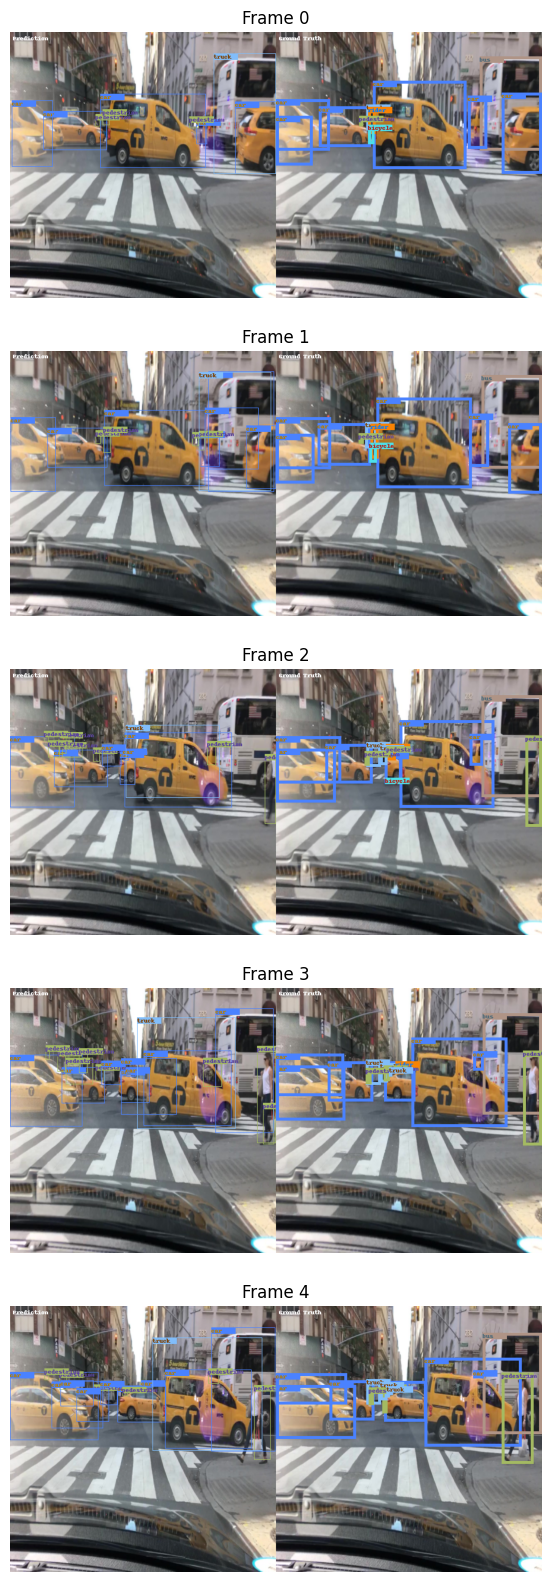

In [10]:
from matplotlib import animation, rcParams
import IPython.display as ipd
# Visualize a few frames
frames = slayer.obd.bbox.utils.create_frames(inputs, bboxes, predictions, test_set.classes)
fig, ax = plt.subplots(figsize=(6, 3))
img_plt = ax.imshow(frames[0])
ax.axis('off')

rcParams['animation.embed_limit'] = 1<<20
anim = animation.FuncAnimation(fig, lambda i: img_plt.set_data(frames[i]),
                               frames=len(frames), interval=40, repeat=True)
plt.close(fig)

num_frames = 5
fig, ax = plt.subplots(num_frames, 1, figsize=(8, 4 * num_frames))
for i in range(num_frames):
    ax[i].imshow(frames[i])
    ax[i].axis('off')
    ax[i].set_title(f'Frame {i}')

In [11]:
# Visualize video
anim.save('yolo_output.mp4', writer=animation.FFMpegWriter())
ipd.Video('yolo_output.mp4')